# **Import Libraries**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

# **Load the Dataset**

## **We'll load the dataset and check its shape.**

In [2]:
df=pd.read_csv('/content/Student Social Media And Mental Health Impact.csv')

In [5]:
df.sample(10)

,Age,Gender,Country,Academic_Level,Most_Used_Platform,Purpose_Of_Use,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Stress_Level,Mental_Health_Score
1359,22,Male,Canada,Undergraduate,TikTok,Entertainment,5.0,154,3.3,2.3,7.2,Medium,6.0
2303,24,Male,Other,Graduate,Snapchat,Entertainment,5.9,204,1.0,2.2,4.7,High,4.9
974,18,Female,Other,High School,YouTube,Education,6.3,209,1.3,1.4,5.5,High,4.2
2329,19,Female,France,Undergraduate,Instagram,Entertainment,4.6,156,5.6,0.9,7.9,Medium,7.0
2798,19,Male,India,Undergraduate,YouTube,Education,6.6,224,2.0,2.1,5.9,Very High,5.9
3015,22,Male,Other,Undergraduate,Twitter,News,5.4,189,3.8,2.0,6.4,High,7.0
3538,19,Female,Netherlands,Undergraduate,TikTok,Entertainment,4.2,119,3.6,1.1,8.1,High,8.5
4752,22,Male,Germany,Undergraduate,Facebook,Networking,4.1,155,2.8,1.3,8.3,Medium,7.1
2770,22,Male,Canada,Undergraduate,TikTok,Entertainment,4.2,145,4.9,2.1,8.2,Medium,6.1
4093,19,Female,India,Undergraduate,WhatsApp,Education,6.7,231,0.9,1.8,6.1,Very High,5.3


In [4]:
df.shape

(5000, 13)

# **Check for Null Values**

In [6]:
df.isnull().sum()

,0
Age,0
Gender,0
Country,0
Academic_Level,0
Most_Used_Platform,0
Purpose_Of_Use,0
Avg_Daily_Usage_Hours,0
Daily_Unlocks,0
Study_Hours,0
Physical_Activity_Hours,0


# **Check for Duplicacy**

In [7]:
df.duplicated().sum()

np.int64(2)

In [8]:
'''there are 2 duplicate rows'''

'there are 2 duplicate rows'

In [9]:
df[df.duplicated()]

,Age,Gender,Country,Academic_Level,Most_Used_Platform,Purpose_Of_Use,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Stress_Level,Mental_Health_Score
2405,19,Female,Other,Undergraduate,LinkedIn,Education,6.1,202,1.0,2.1,5.8,High,4.1
2463,21,Male,USA,Undergraduate,Snapchat,Entertainment,3.9,126,5.1,2.6,7.1,Low,7.5


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      5000 non-null   int64  
 1   Gender                   5000 non-null   object 
 2   Country                  5000 non-null   object 
 3   Academic_Level           5000 non-null   object 
 4   Most_Used_Platform       5000 non-null   object 
 5   Purpose_Of_Use           5000 non-null   object 
 6   Avg_Daily_Usage_Hours    5000 non-null   float64
 7   Daily_Unlocks            5000 non-null   int64  
 8   Study_Hours              5000 non-null   float64
 9   Physical_Activity_Hours  5000 non-null   float64
 10  Sleep_Hours_Per_Night    5000 non-null   float64
 11  Stress_Level             5000 non-null   object 
 12  Mental_Health_Score      5000 non-null   float64
dtypes: float64(5), int64(2), object(6)
memory usage: 507.9+ KB


In [11]:
df.describe()

,Age,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Mental_Health_Score
count,5000.00000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,20.82180,5.078460,171.452600,3.008420,1.751000,6.634580,6.230980
std,1.73662,1.653913,42.858254,1.637018,0.668398,1.221391,1.278701
min,18.00000,1.000000,62.000000,0.300000,-0.400000,3.600000,3.600000
25%,19.00000,3.800000,140.000000,1.500000,1.300000,5.600000,5.100000
50%,21.00000,5.000000,171.000000,2.800000,1.700000,6.600000,6.100000
75%,22.00000,6.300000,204.000000,4.200000,2.200000,7.500000,7.100000
max,24.00000,8.800000,273.000000,8.300000,4.100000,9.900000,9.400000


In [13]:
''' On Inspecting the Descriptive Statistics, we found that Physical_Activity_Hours column has  minimum value of -0.40000, which is absolutely impractical, so we need to handle it '''

' On Inspecting the Descriptive Statistics, we found that Physical_Activity_Hours column has  minimum value of -0.40000, which is absolutely impractical, so we need to handle it '

# **Exploratory Data Analysis**

# **Check the Distribution of Target Variable**

<Axes: xlabel='Mental_Health_Score', ylabel='Count'>

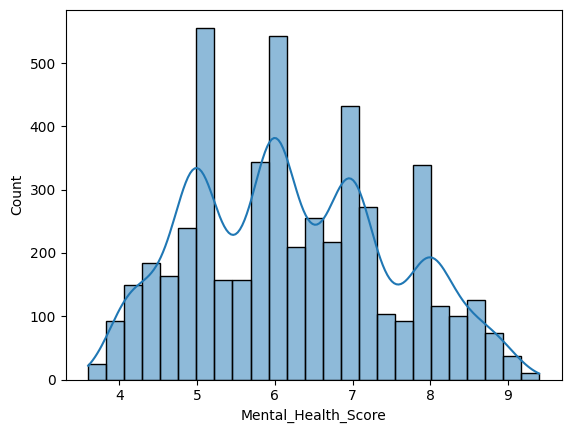

In [15]:
sns.histplot(df['Mental_Health_Score'],kde=True)

In [18]:
''' Before Predicting anything, we firstly need to check the distribution of what we are predicting '''

' Before Predicting anything, we firstly need to check the distribution of what we are predicting '

# **Correlation Heatmap**

# **To See which numeric features contributes to the target variable**

<Axes: >

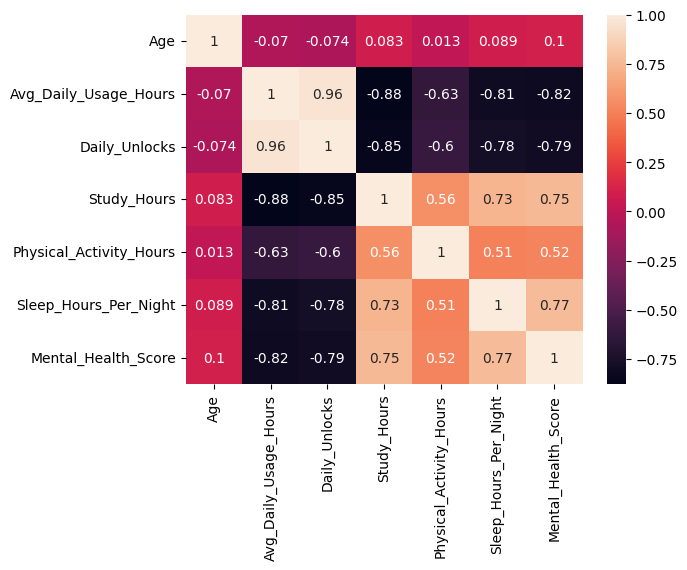

In [21]:
sns.heatmap(df.corr(numeric_only=True),annot=True)

In [59]:
df.columns

Index(['Age', 'Gender', 'Country', 'Academic_Level', 'Most_Used_Platform',
       'Purpose_Of_Use', 'Avg_Daily_Usage_Hours', 'Daily_Unlocks',
       'Study_Hours', 'Physical_Activity_Hours', 'Sleep_Hours_Per_Night',
       'Stress_Level', 'Mental_Health_Score'],
      dtype='object')

# **Now, check the relation between Stress Level with Mental Health Score**

In [22]:
df['Stress_Level'].unique()

array(['Medium', 'Low', 'Very High', 'High'], dtype=object)

In [94]:
df['Stress_Level'].value_counts()

,count
Stress_Level,
Very High,1621
High,1440
Medium,1295
Low,644


Text(0.5, 1.0, 'More Stress Level relates to low Mental Health Score')

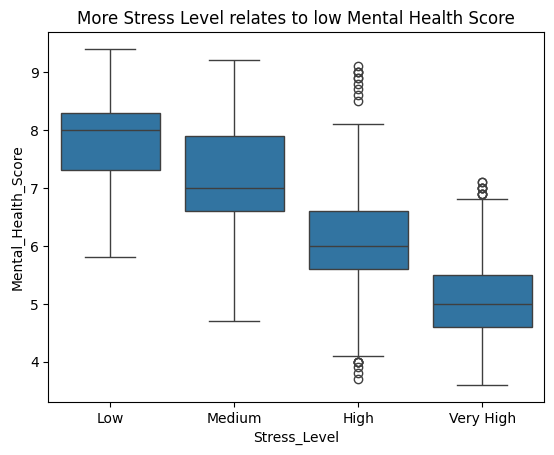

In [62]:
order=['Low','Medium','High','Very High']
sns.boxplot(data=df,x='Stress_Level',y='Mental_Health_Score',order=order)
plt.title('More Stress Level relates to low Mental Health Score')

# **Check which Purpose of use was most common**


Text(0.5, 1.0, 'Entertainment Purpose was most common for using Social Media')

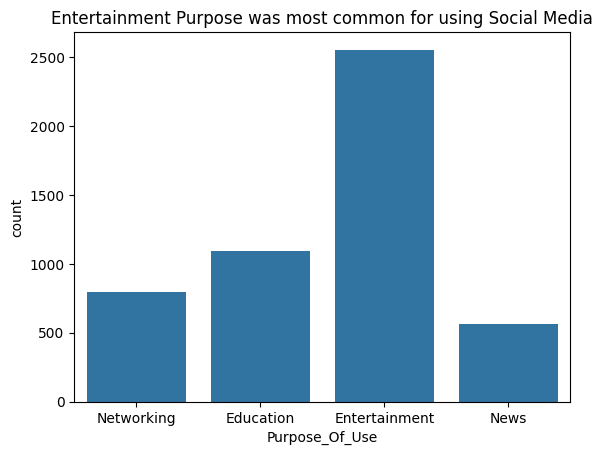

In [65]:
sns.countplot(data=df,x=df['Purpose_Of_Use'])
plt.title('Entertainment Purpose was most common for using Social Media')

Text(0.5, 1.0, 'No as such strong relationship between Purpose of Use and Mental Health Score')

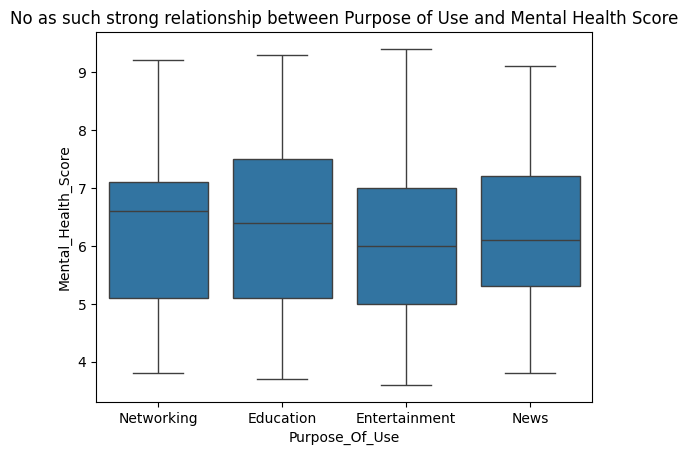

In [73]:
sns.boxplot(data=df,x='Purpose_Of_Use',y='Mental_Health_Score')
plt.title('No as such strong relationship between Purpose of Use and Mental Health Score')

# **Check relation between Academic Level and Mental Health Score**

In [68]:
df['Academic_Level'].value_counts()

,count
Academic_Level,
Undergraduate,3632
Graduate,918
High School,450


<Axes: xlabel='Academic_Level'>

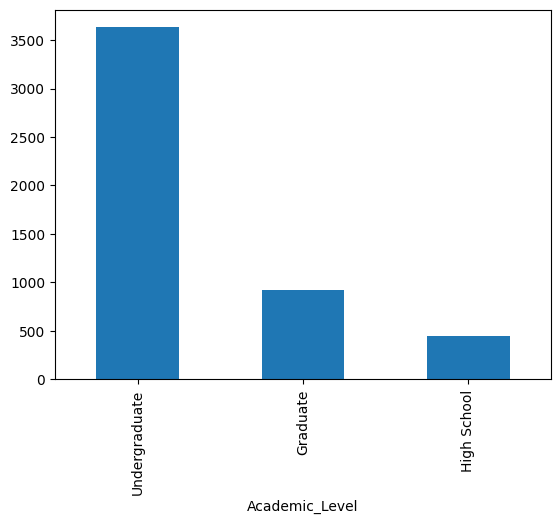

In [67]:
df['Academic_Level'].value_counts().plot(kind='bar')

Text(0.5, 1.0, 'No as such strong relationship between Academic Level and Mental Health Score')

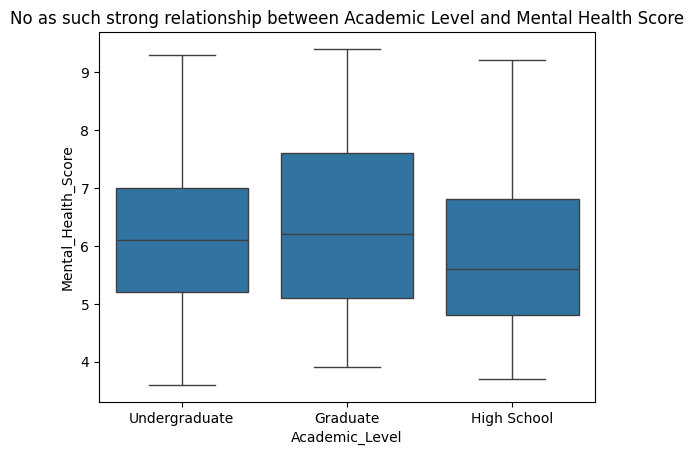

In [71]:
sns.boxplot(data=df,x='Academic_Level',y='Mental_Health_Score')
plt.title('No as such strong relationship between Academic Level and Mental Health Score')

# **Daily Usage Hours vs Mental Health Score**

Text(0.5, 1.0, 'More Avg Daily Usage Hours relate to low Mental Health Score')

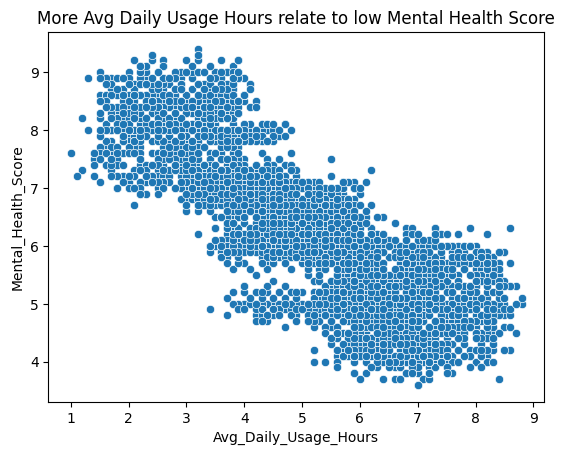

In [28]:
# since, both are numerical so, we'll use scatterplot
sns.scatterplot(x='Avg_Daily_Usage_Hours',data=df,y='Mental_Health_Score')
plt.title('More Avg Daily Usage Hours relate to low Mental Health Score')

# **Sleep Hour vs Mental Health Score**

Text(0.5, 1.0, 'More Sleep Hours related to More Mental Health Score')

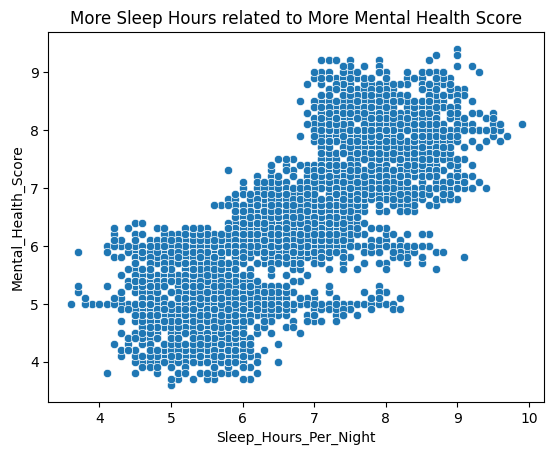

In [32]:
sns.scatterplot(data=df,x='Sleep_Hours_Per_Night',y='Mental_Health_Score')
plt.title('More Sleep Hours related to More Mental Health Score')

# **Relationship between Age and Mental health Score**

Text(0.5, 1.0, 'No as such strong relation between Age and Mental Health Score')

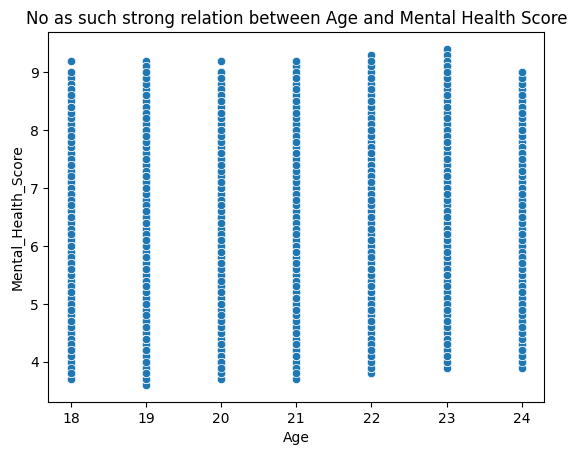

In [99]:
# since, both are numerical so, we'll use scatterplot
sns.scatterplot(x='Age',data=df,y='Mental_Health_Score')
plt.title('No as such strong relation between Age and Mental Health Score')

# **Check relation between Daily Unlocks Vs Mental health Score**

Text(0.5, 1.0, 'strong -ve relation between Daily Unlocks and Mental Health Score')

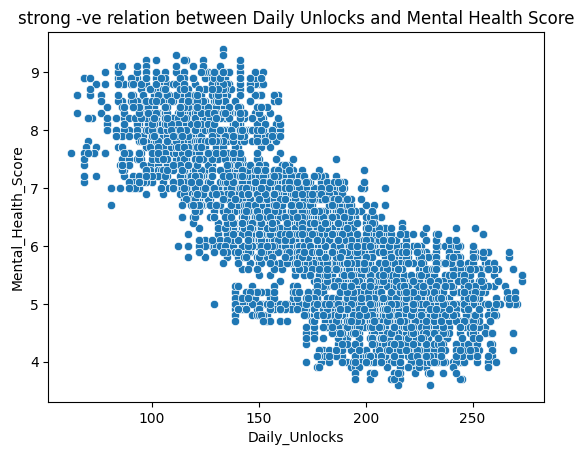

In [101]:
# since, both are numerical so, we'll use scatterplot
sns.scatterplot(x='Daily_Unlocks',data=df,y='Mental_Health_Score')
plt.title('strong -ve relation between Daily Unlocks and Mental Health Score')

# **Relation between Study Hours and Mental Health Score**

Text(0.5, 1.0, 'strong +ve relation between Study Hours and Mental Health Score')

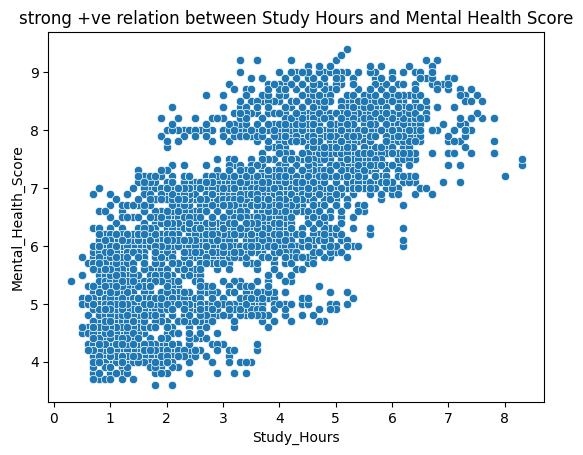

In [103]:
# since, both are numerical so, we'll use scatterplot
sns.scatterplot(x='Study_Hours',data=df,y='Mental_Health_Score')
plt.title('strong +ve relation between Study Hours and Mental Health Score')

# **Relation between Physical Activity Hours vs Mental Health Score**

Text(0.5, 1.0, 'somehow Medium +ve relation between Physical Activity Hours and Mental Health Score')

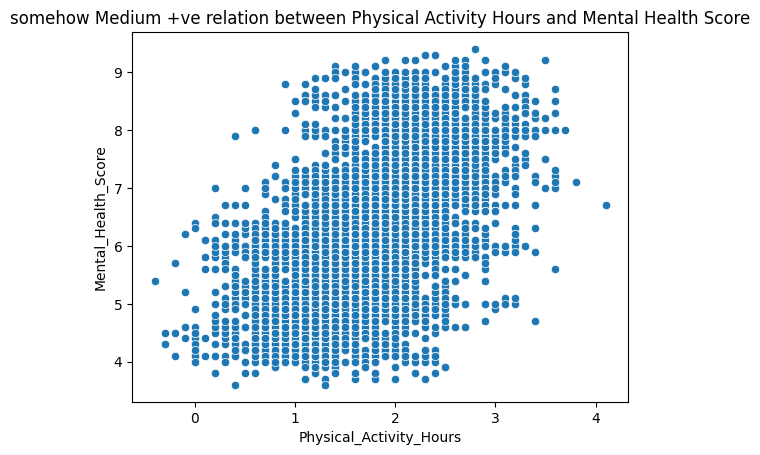

In [105]:
# since, both are numerical so, we'll use scatterplot
sns.scatterplot(x='Physical_Activity_Hours',data=df,y='Mental_Health_Score')
plt.title('somehow Medium +ve relation between Physical Activity Hours and Mental Health Score')

In [97]:
df.columns

Index(['Age', 'Gender', 'Country', 'Academic_Level', 'Most_Used_Platform',
       'Purpose_Of_Use', 'Avg_Daily_Usage_Hours', 'Daily_Unlocks',
       'Study_Hours', 'Physical_Activity_Hours', 'Sleep_Hours_Per_Night',
       'Stress_Level', 'Mental_Health_Score'],
      dtype='object')

# **Most Used Platforms**

Text(0.5, 1.0, 'Instagram is Most Commonly used Platform in our Dataset')

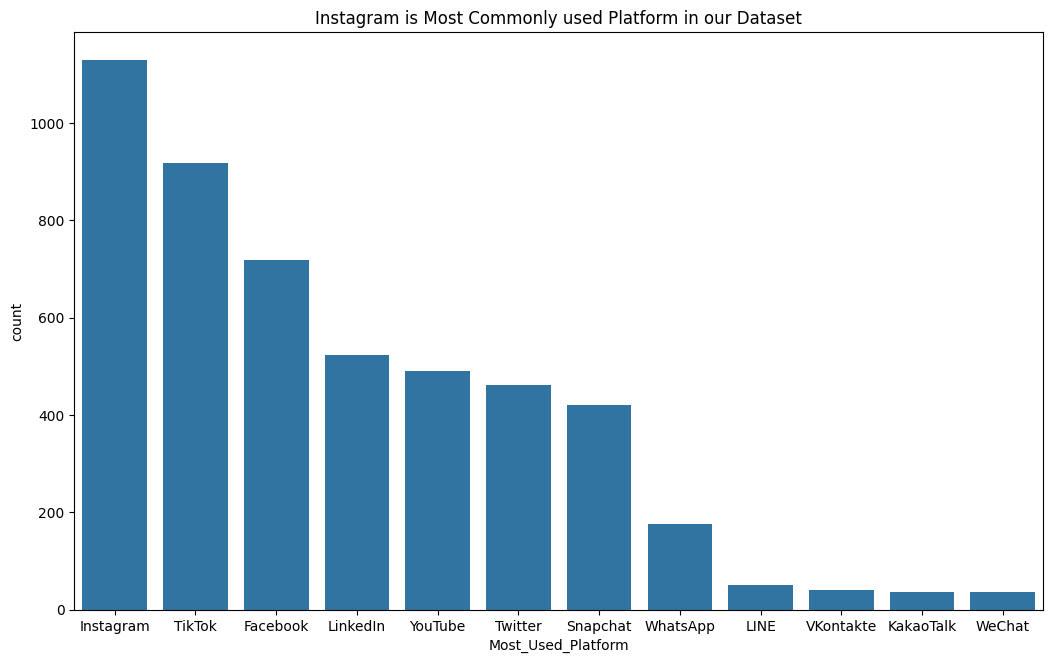

In [58]:
plt.figure(figsize=(12.5,7.5))
sns.countplot(data=df,x=df['Most_Used_Platform'],order=df['Most_Used_Platform'].value_counts().index)
plt.title('Instagram is Most Commonly used Platform in our Dataset')

Text(0.5, 1.0, 'No as such strong relationship between Most Used Platform and Mental Health Score')

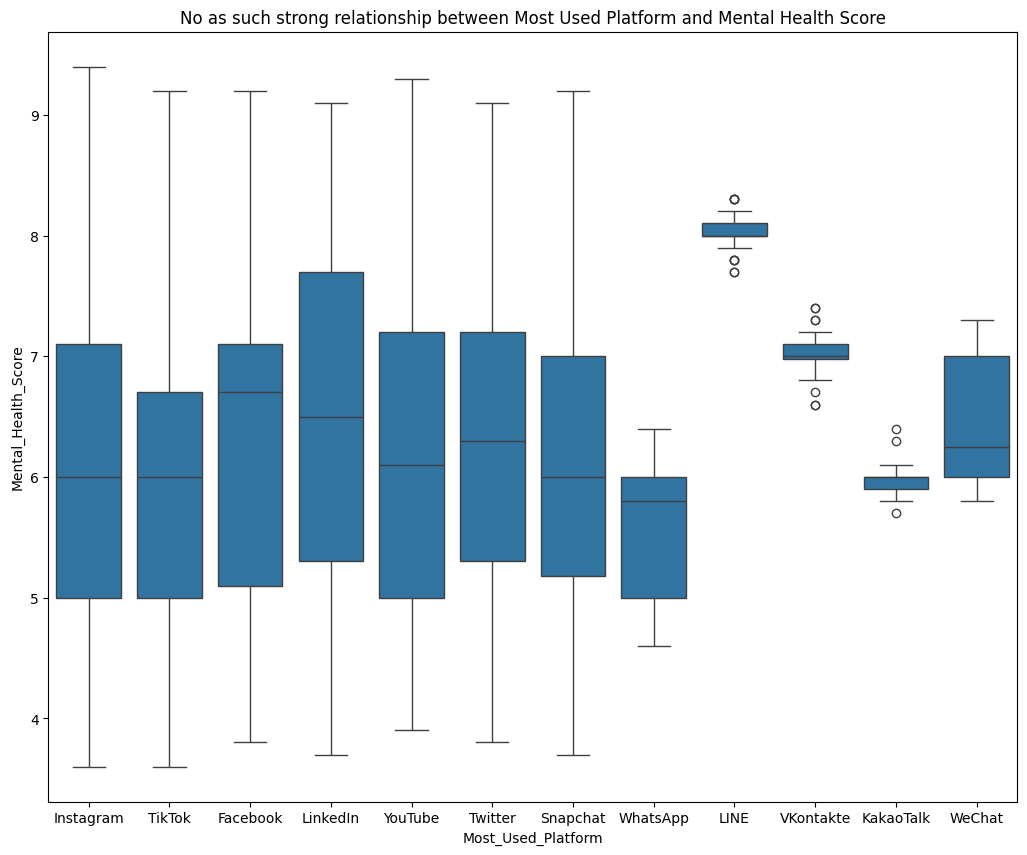

In [78]:
plt.figure(figsize=(12.5,10))
sns.boxplot(data=df,x='Most_Used_Platform',y='Mental_Health_Score',order=df['Most_Used_Platform'].value_counts().index)
plt.title('No as such strong relationship between Most Used Platform and Mental Health Score')

# **Check relation between Gender and mental health score**

Text(0.5, 1.0, 'As such no any strong relationship between Mental Health Score and Gender')

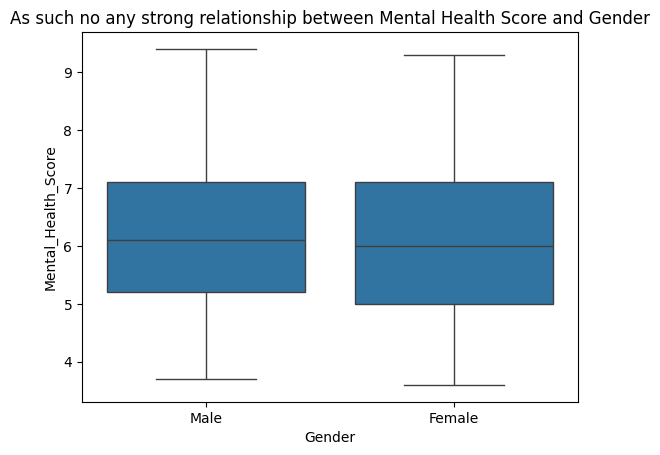

In [89]:
sns.boxplot(data=df,x='Gender',y='Mental_Health_Score')
plt.title('As such no any strong relationship between Mental Health Score and Gender')

# **Note that there's no sense for checking relation between country and mental health score**

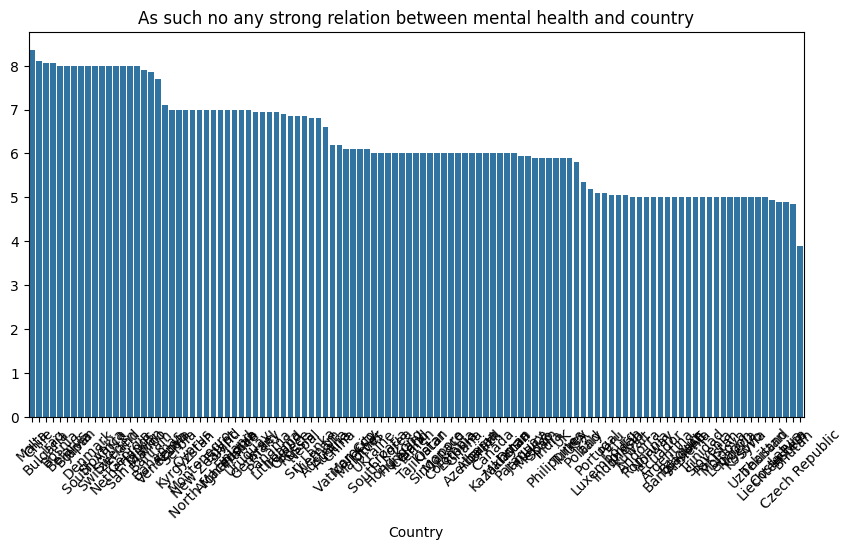

In [92]:
# Country-wise Median Mental Health Score
country_mh = (
    df.groupby('Country')['Mental_Health_Score']
    .median()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 5))
sns.barplot(x=country_mh.index, y=country_mh.values)
plt.title('Median Mental Health Score by Country')
plt.title('As such no any strong relation between mental health and country')
plt.xticks(rotation=45)
plt.show()

# **Checking Outliers in Numerical Features**

In [111]:
numerical_features=df.select_dtypes(include='number')
numerical_features
Q1=numerical_features.quantile(0.25)
Q3=numerical_features.quantile(0.75)
IQR=Q3-Q1
lower_bound , upper_bound = Q1-1.5*IQR , Q3+1.5*IQR
outlier_features=(numerical_features > upper_bound) | (numerical_features < lower_bound)
outlier_features.sum()



,0
Age,0
Avg_Daily_Usage_Hours,0
Daily_Unlocks,0
Study_Hours,2
Physical_Activity_Hours,22
Sleep_Hours_Per_Night,0
Mental_Health_Score,0


<Axes: ylabel='Physical_Activity_Hours'>

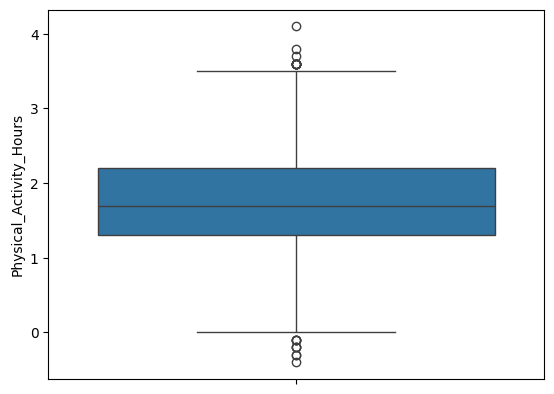

In [121]:
# We can also make Box plot to see the outliers
sns.boxplot(df['Physical_Activity_Hours'])

<Axes: ylabel='Study_Hours'>

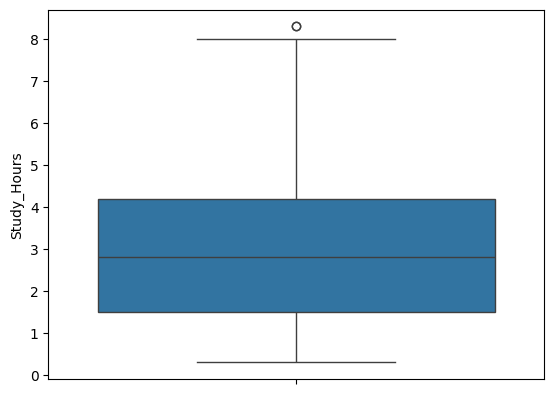

In [122]:
sns.boxplot(df['Study_Hours'])

In [112]:
''' We can ignore these outliers as they are very less in comparison to our Entire Dataset'''

' We can ignore these outliers as they are very less in comparison to our Entire Dataset'

# **Data Cleaning**

In [127]:
# 1) Drop Duplicates
df.drop_duplicates(inplace=True)

In [131]:
# 2) Convert Unrealistic minimum value of Physical_Activity_Hours from -0.4 to 0 (which seems to be realistic)
df['Physical_Activity_Hours']=df['Physical_Activity_Hours'].clip(lower=0)

In [132]:
df.describe()

,Age,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Mental_Health_Score
count,4998.000000,4998.000000,4998.000000,4998.000000,4998.000000,4998.000000,4998.000000
mean,20.822129,5.078491,171.455582,3.008403,1.751160,6.634654,6.231152
std,1.736774,1.654097,42.859829,1.636831,0.667282,1.221561,1.278476
min,18.000000,1.000000,62.000000,0.300000,0.000000,3.600000,3.600000
25%,19.000000,3.800000,140.000000,1.500000,1.300000,5.600000,5.100000
50%,21.000000,5.000000,171.000000,2.800000,1.700000,6.600000,6.100000
75%,22.000000,6.300000,204.000000,4.200000,2.200000,7.500000,7.100000
max,24.000000,8.800000,273.000000,8.300000,4.100000,9.900000,9.400000


# **Skewness**

In [134]:
numerical_features.skew()

,0
Age,0.155325
Avg_Daily_Usage_Hours,0.005606
Daily_Unlocks,0.002351
Study_Hours,0.435819
Physical_Activity_Hours,0.039971
Sleep_Hours_Per_Night,0.124050
Mental_Health_Score,0.206567


<Axes: xlabel='Age', ylabel='Density'>

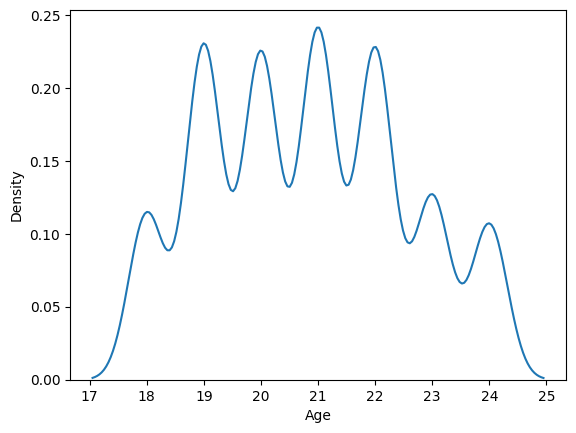

In [135]:
# We also can visually check the distribution of numeric features
sns.kdeplot(data=numerical_features['Age'])

<Axes: xlabel='Avg_Daily_Usage_Hours', ylabel='Density'>

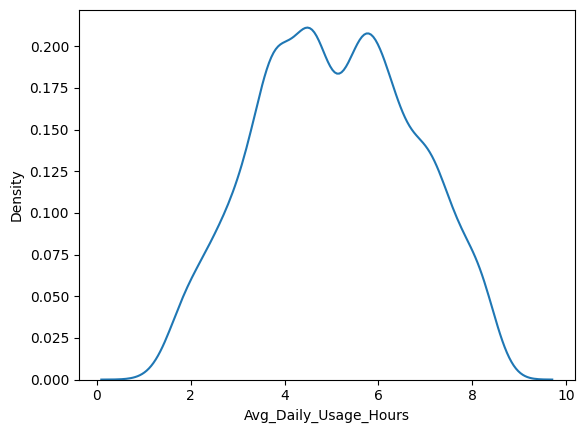

In [136]:
sns.kdeplot(data=numerical_features['Avg_Daily_Usage_Hours'])

<Axes: xlabel='Daily_Unlocks', ylabel='Density'>

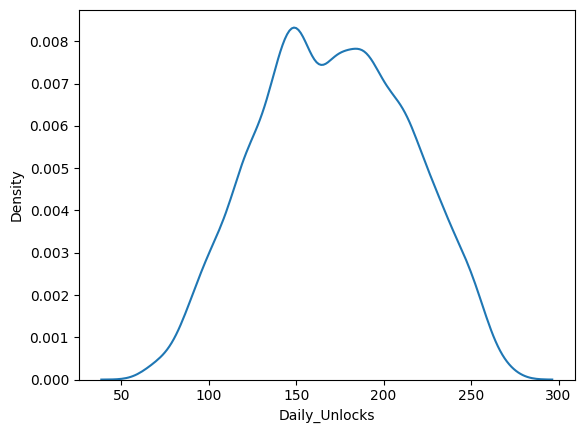

In [138]:
sns.kdeplot(data=numerical_features['Daily_Unlocks'])

<Axes: xlabel='Study_Hours', ylabel='Density'>

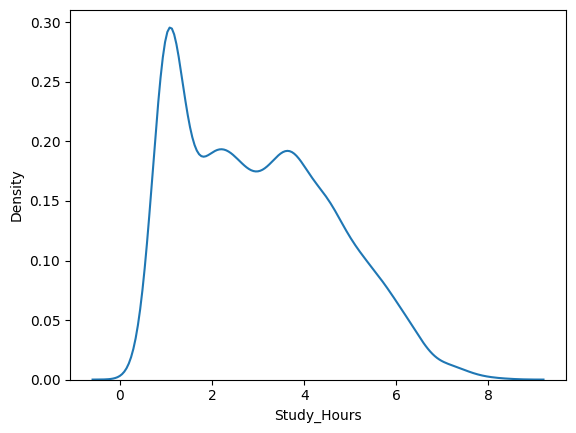

In [139]:
sns.kdeplot(data=numerical_features['Study_Hours'])

<Axes: xlabel='Physical_Activity_Hours', ylabel='Density'>

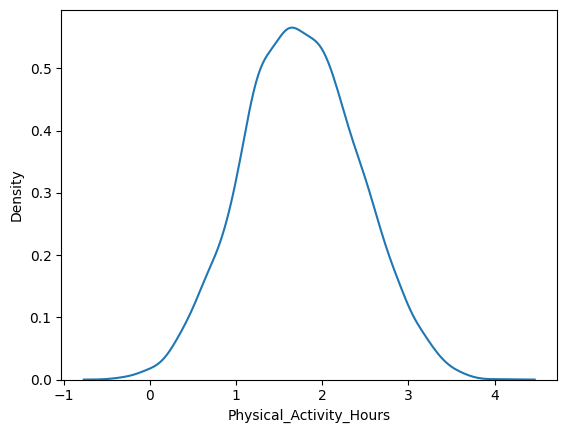

In [140]:
sns.kdeplot(data=numerical_features['Physical_Activity_Hours'])

<Axes: xlabel='Sleep_Hours_Per_Night', ylabel='Density'>

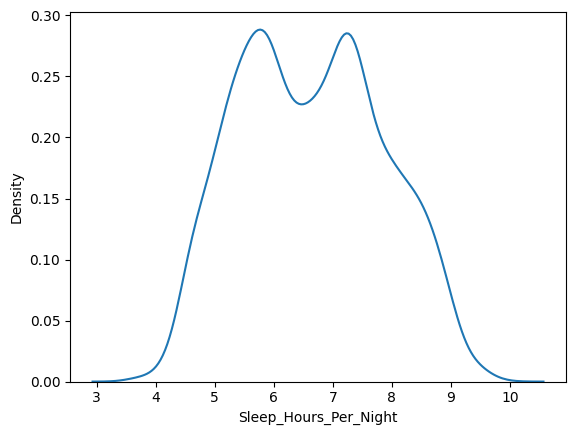

In [141]:
sns.kdeplot(df['Sleep_Hours_Per_Night'])

<Axes: xlabel='Mental_Health_Score', ylabel='Density'>

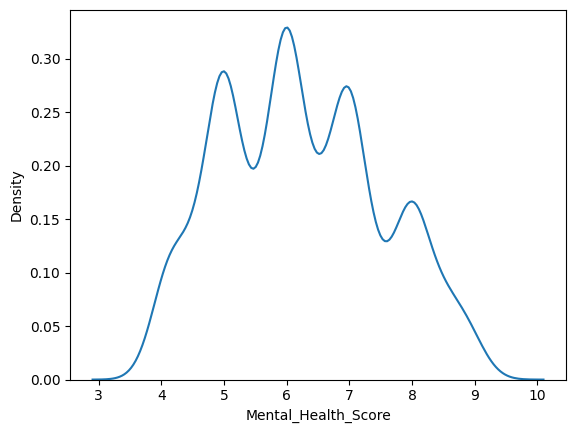

In [142]:
sns.kdeplot(df['Mental_Health_Score'])

# **Although, all these numeric features are not perfectly normal**

# **Feature Engineering**

In [153]:
# Country Column-: applying OHE on this feature would unnecessarily increase dimensionality of dataset
# so we would decide to fetch top 10 countries based on their count and bucket rest of the countries into Other Category
top_countries=df['Country'].value_counts().index[:10].tolist()
top_countries

['Other',
 'India',
 'USA',
 'Canada',
 'Australia',
 'UK',
 'Germany',
 'Mexico',
 'Turkey',
 'France']

In [154]:
def group_countries(country):
  if country in top_countries:
    return country
  else:
    return 'Other'


In [156]:
df['Grouped_Country']=df['Country'].apply(group_countries)

In [165]:
df['Grouped_Country'].value_counts()

,count
Grouped_Country,
Other,3231
India,389
USA,354
Canada,230
Australia,198
UK,185
Germany,136
Mexico,94
Turkey,94


In [167]:
df.columns

Index(['Age', 'Gender', 'Country', 'Academic_Level', 'Most_Used_Platform',
       'Purpose_Of_Use', 'Avg_Daily_Usage_Hours', 'Daily_Unlocks',
       'Study_Hours', 'Physical_Activity_Hours', 'Sleep_Hours_Per_Night',
       'Stress_Level', 'Mental_Health_Score', 'Grouped_Country'],
      dtype='object')

In [195]:
skewed_features=['Study_Hours'] # apply log transformation because it is right skewed
unskewed_features=['Age','Avg_Daily_Usage_Hours', 'Daily_Unlocks','Physical_Activity_Hours', 'Sleep_Hours_Per_Night']
# apply something different on these unskewed features but not log transformation
ordinal_features=['Stress_Level'] # preserve the inherent order
nominal_features=['Gender', 'Grouped_Country', 'Academic_Level', 'Most_Used_Platform','Purpose_Of_Use'] # apply OHE

inputs_feature=skewed_features+unskewed_features+ordinal_features+nominal_features # Input Features
X,Y=df[inputs_feature],df['Mental_Health_Score'] # target features


# **Perform Train:Test Split**

In [196]:
from sklearn.model_selection import train_test_split
X_train,X_test,Y_train,Y_test = train_test_split(X,Y,test_size=0.20,random_state=40)

# **Preprocessing using Column Transformer**

## **Build Pipelines for the Purpose of Data Preprocessing to  handle -:**
### **skewed feature**
### **unskewed feature**
### **ordinal feature**
### **nominal feature**


In [197]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer,StandardScaler, OrdinalEncoder,OneHotEncoder
from sklearn.compose import ColumnTransformer
# 1) Pipeline for Skewed Feature
skewed_pipeline=Pipeline(steps=[('log_transform',FunctionTransformer(np.log1p)),('standard_scaling',StandardScaler())])

# 2) Pipeline for UnSkewed Feature
unskewed_pipeline=Pipeline(steps=[('standard_scaling',StandardScaler())])

# 3) Pipeline for ordinal Feature
ordinal_pipeline=Pipeline(steps=[('Ordinal_Encoding',OrdinalEncoder(categories=[['Low','Medium','High','Very High']]))])

# 4) Pipeline for Nominal Feature
nominal_pipeline=Pipeline(steps=[('Nominal_Encoding',OneHotEncoder(handle_unknown='ignore'))])

preprocessor=ColumnTransformer(transformers=[
    ('skewed_pipeline',skewed_pipeline,skewed_features),
    ('unskewed_pipeline',unskewed_pipeline,unskewed_features),
    ('ordinal_pipeline',ordinal_pipeline,ordinal_features),
    ('nominal_pipeline',nominal_pipeline,nominal_features)
])


# **Now, Build Pipelines for Models being used**

### **Baseline Model: Linear Regression**

In [203]:
from sklearn.linear_model import LinearRegression,RidgeCV,LassoCV,ElasticNetCV
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error

In [202]:
lr_pipeline=Pipeline(steps=[('preprocessor',preprocessor),('regressor',LinearRegression())])
lr_pipeline.fit(X_train,Y_train)
lr_test_predictions=lr_pipeline.predict(X_test)
lr_train_predictions=lr_pipeline.predict(X_train)

lr_r2_test_score=r2_score(Y_test , lr_test_predictions)
lr_mae_test_score=mean_absolute_error(Y_test , lr_test_predictions)

lr_r2_train_score=r2_score(Y_train , lr_train_predictions)
lr_mae_train_score=mean_absolute_error(Y_train , lr_train_predictions)

print(f'R2 Score by Linear Regression on Train Corpus is f {lr_r2_train_score}')
print(f'R2 Score by Linear Regression on Test Corpus is f {lr_r2_test_score}')

print(f'MAE by Linear Regression on Train Corpus is f {lr_mae_train_score}')
print(f'MAE by Linear Regression on Test Corpus is f {lr_mae_test_score}')


R2 Score by Linear Regression on Train Corpus is f 0.7333926033513357
R2 Score by Linear Regression on Test Corpus is f 0.7142576368023508
MAE by Linear Regression on Train Corpus is f 0.517727233163795
MAE by Linear Regression on Test Corpus is f 0.5463315256717886


# **Random Forest #(Default Settings)**

In [217]:
from sklearn.ensemble import RandomForestRegressor
rf_pipeline=Pipeline(steps=[('preprocessor',preprocessor),('rf_regressor',RandomForestRegressor(random_state=42))])
rf_pipeline.fit(X_train,Y_train)
rf_train_predictions=rf_pipeline.predict(X_train)
rf_test_predictions=rf_pipeline.predict(X_test)

rf_r2_score_test=r2_score(Y_test,rf_test_predictions)
rf_r2_score_train=r2_score(Y_train,rf_train_predictions)

rf_mae_test=mean_absolute_error(Y_test,rf_test_predictions)
rf_mae_train=mean_absolute_error(Y_train,rf_train_predictions)

print(f'r2 score by Random Forest Regressor on Train Data f {rf_r2_score_train}')
print(f'r2 score by Random Forest Regressor on Test Data f {rf_r2_score_test}')

print(f'MAE by Random Forest Regressor on Train Data f {rf_mae_train}')
print(f'MAE by Random Forest Regressor on Test Data f {rf_mae_test}')


r2 score by Random Forest Regressor on Train Data f 0.9833307702571927
r2 score by Random Forest Regressor on Test Data f 0.8720381417515557
MAE by Random Forest Regressor on Train Data f 0.12012036018009022
MAE by Random Forest Regressor on Test Data f 0.3359941


# **Random Forest Regressor with Hyperparameter Tuning**

In [218]:
from sklearn.model_selection import RandomizedSearchCV

param_grid={
    'rf_regressor__n_estimators':[100,200,500,750,770,875,930,975,1000],
    'rf_regressor__max_depth':[5,10,15,20,30,18],
    'rf_regressor__min_samples_split':[2,3,5,8,10],
    'rf_regressor__min_samples_leaf':[1,3,4,5,7,9,10]
}

random_search=RandomizedSearchCV(estimator=rf_pipeline,
                   param_distributions=param_grid,
                   n_iter=50,
                   cv=5,
                   scoring='r2',
                   n_jobs=-1,
                   random_state=42
                   )

random_search.fit(X_train,Y_train)

RandomizedSearchCV(cv=5,
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(transformers=[('skewed_pipeline',
                                                                               Pipeline(steps=[('log_transform',
                                                                                                FunctionTransformer(func=<ufunc 'log1p'>)),
                                                                                               ('standard_scaling',
                                                                                                StandardScaler())]),
                                                                               ['Study_Hours']),
                                                                              ('unskewed_pipeline',
                                                                               Pipeline(steps=[('standard_scaling',
                                                                                                StandardScaler())]),
                                                                               ['Age',
                                                                                'Avg_Daily_Usage_...
                                                                                'Purpose_Of_Use'])])),
                                             ('rf_regressor',
                                              RandomForestRegressor(random_state=42))]),
                   n_iter=50, n_jobs=-1,
                   param_distributions={'rf_regressor__max_depth': [5, 10, 15,
                                                                    20, 30,
                                                                    18],
                                        'rf_regressor__min_samples_leaf': [1, 3,
                                                                           4, 5,
                                                                           7, 9,
                                                                           10],
                                        'rf_regressor__min_samples_split': [2,
                                                                            3,
                                                                            5,
                                                                            8,
                                                                            10],
                                        'rf_regressor__n_estimators': [100, 200,
                                                                       500, 750,
                                                                       770, 875,
                                                                       930, 975,
                                                                       1000]},
                   random_state=42, scoring='r2')

In [226]:
rf_best_parameters=random_search.best_params_
rf_best_pipeline=random_search.best_estimator_
rf_train_rs_predictions=rf_best_pipeline.predict(X_train)
rf_test_rs_predictions=rf_best_pipeline.predict(X_test)

print(f'r2 score of Random Forest on Train Data after Randomized Search is {r2_score(Y_train,rf_train_rs_predictions)}')
print(f'r2 score of Random Forest on Test Data after Randomized Search is {r2_score(Y_test,rf_test_rs_predictions)}')

print(f'MAE score of Random Forest on Train Data after Randomized Search is {mean_absolute_error(Y_train,rf_train_rs_predictions)}')
print(f'MAE score of Random Forest on Test Data after Randomized Search is {mean_absolute_error(Y_test,rf_test_rs_predictions)}')




r2 score of Random Forest on Train Data after Randomized Search is 0.9790464859189987
r2 score of Random Forest on Test Data after Randomized Search is 0.8714104038798882
MAE score of Random Forest on Train Data after Randomized Search is 0.1377881166198966
MAE score of Random Forest on Test Data after Randomized Search is 0.3399409066312141


# **Model Evaluation**

In [232]:
print('Linear Regression Model (without Hyperparameter Tuning)')
print(f'R2 Score by Linear Regression on Train Corpus is f {lr_r2_train_score}')
print(f'R2 Score by Linear Regression on Test Corpus is f {lr_r2_test_score}')

print(f'MAE by Linear Regression on Train Corpus is f {lr_mae_train_score}')
print(f'MAE by Linear Regression on Test Corpus is f {lr_mae_test_score}')
print(200*'*')

print('Random Forest Regressor Before Randomized Search')
print(f'r2 score by Random Forest Regressor on Train Data f {rf_r2_score_train}')
print(f'r2 score by Random Forest Regressor on Test Data f {rf_r2_score_test}')

print(f'MAE by Random Forest Regressor on Train Data f {rf_mae_train}')
print(f'MAE by Random Forest Regressor on Test Data f {rf_mae_test}')
print(200*'*')

print('Random Forest Regressor After Randomized Search')
print(f'r2 score of Random Forest on Train Data after Randomized Search is {r2_score(Y_train,rf_train_rs_predictions)}')
print(f'r2 score of Random Forest on Test Data after Randomized Search is {r2_score(Y_test,rf_test_rs_predictions)}')

print(f'MAE score of Random Forest on Train Data after Randomized Search is {mean_absolute_error(Y_train,rf_train_rs_predictions)}')
print(f'MAE score of Random Forest on Test Data after Randomized Search is {mean_absolute_error(Y_test,rf_test_rs_predictions)}')
print(200*'*')

Linear Regression Model (without Hyperparameter Tuning)
R2 Score by Linear Regression on Train Corpus is f 0.7333926033513357
R2 Score by Linear Regression on Test Corpus is f 0.7142576368023508
MAE by Linear Regression on Train Corpus is f 0.517727233163795
MAE by Linear Regression on Test Corpus is f 0.5463315256717886
********************************************************************************************************************************************************************************************************
Random Forest Regressor Before Randomized Search
r2 score by Random Forest Regressor on Train Data f 0.9833307702571927
r2 score by Random Forest Regressor on Test Data f 0.8720381417515557
MAE by Random Forest Regressor on Train Data f 0.12012036018009022
MAE by Random Forest Regressor on Test Data f 0.3359941
*******************************************************************************************************************************************************************

# **Tuned Random Forest Model Saving into pickle**

In [234]:
# We'll use Tuned Random Forest Regressor Pipeline named as rf_best_pipeline
import joblib
joblib.dump(rf_best_pipeline,'Mental_Health_Model.pkl')

['Mental_Health_Model.pkl']